###import dataset and show

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
import pandas as pd

zip_path = "/content/drive/MyDrive/StudentsPerformanceinExams_dataset/archive (1).zip"
extract_path = "/content/drive/MyDrive/StudentsPerformanceinExams_dataset/extracted_data"

print("ไฟล์ zip มีอยู่หรือไม่:", os.path.exists(zip_path))

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("แตกไฟล์เรียบร้อยแล้ว")

for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    for file in files:
        print("  -", file)

csv_path = os.path.join(extract_path, "StudentsPerformance.csv")
print("CSV path:", csv_path)
print("CSV exists:", os.path.exists(csv_path))

df = pd.read_csv(csv_path)

print("\nShape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nInfo:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Mounted at /content/drive
ไฟล์ zip มีอยู่หรือไม่: True
แตกไฟล์เรียบร้อยแล้ว
Folder: /content/drive/MyDrive/StudentsPerformanceinExams_dataset/extracted_data
  - StudentsPerformance.csv
CSV path: /content/drive/MyDrive/StudentsPerformanceinExams_dataset/extracted_data/StudentsPerformance.csv
CSV exists: True

Shape: (1000, 8)

Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   mat

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate rows: 0


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
print("Mean math score    :", df["math score"].mean())
print("Mean reading score :", df["reading score"].mean())
print("Mean writing score :", df["writing score"].mean())

Mean math score    : 66.089
Mean reading score : 69.169
Mean writing score : 68.054


###import library

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

###Prepare zone & EDA

In [8]:
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


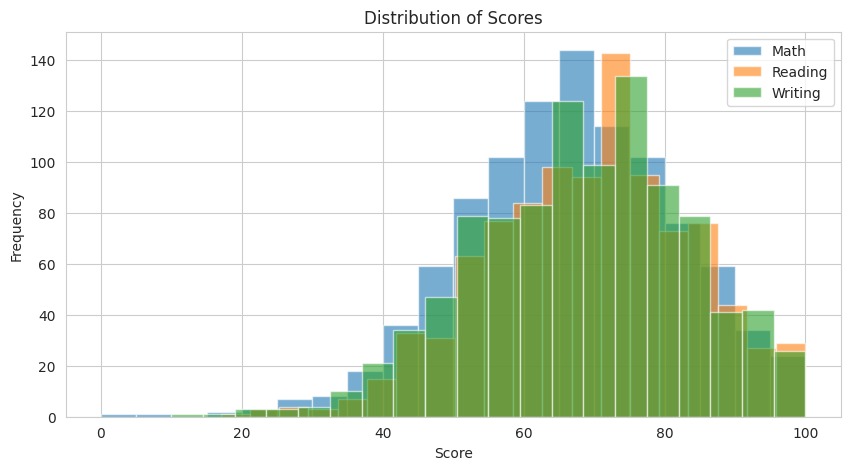

In [9]:
#for watch range of data
plt.figure(figsize=(10, 5))
plt.hist(df["math score"], bins=20, alpha=0.6, label="Math")
plt.hist(df["reading score"], bins=20, alpha=0.6, label="Reading")
plt.hist(df["writing score"], bins=20, alpha=0.6, label="Writing")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Scores")
plt.legend()
plt.show()

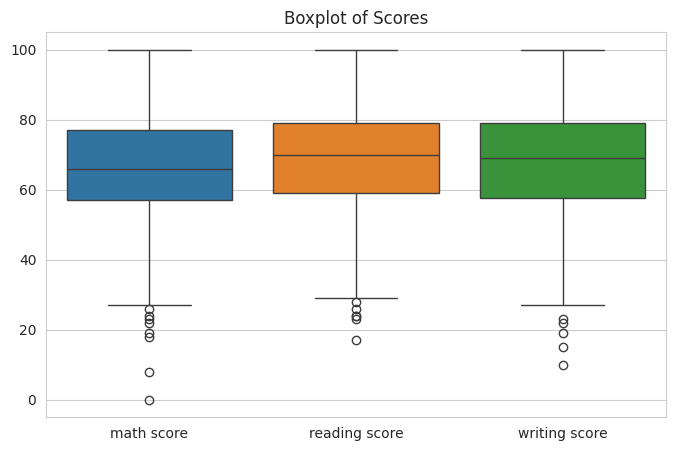

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["math score", "reading score", "writing score"]])
plt.title("Boxplot of Scores")
plt.show()

In [11]:
#watching gender counts
df["gender"].value_counts()

,count
gender,
female,518
male,482


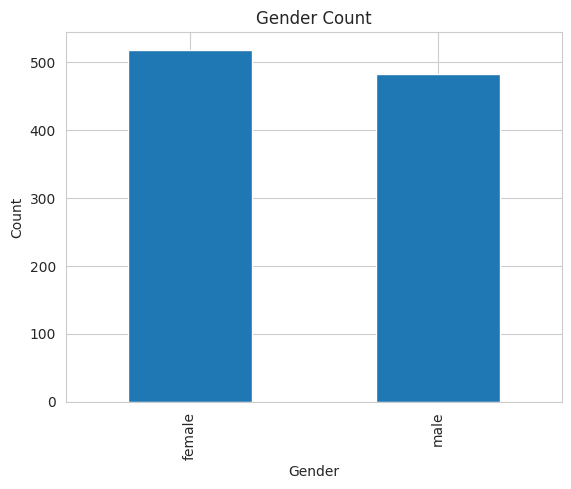

In [12]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [13]:
#test preparation course
df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


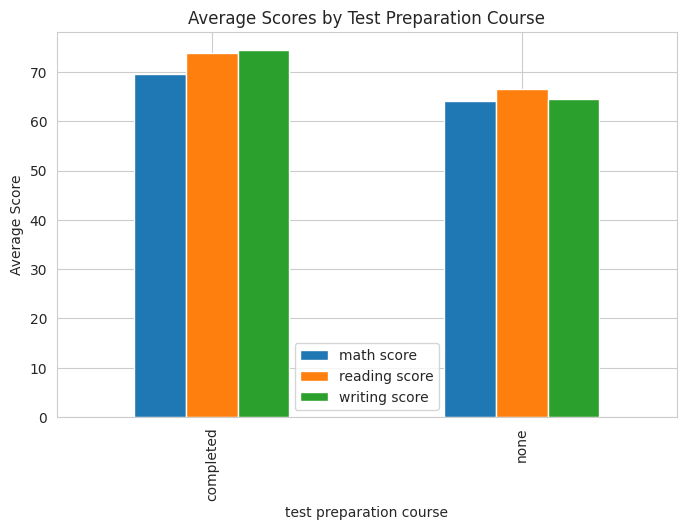

In [14]:
df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean().plot(kind="bar", figsize=(8,5))
plt.title("Average Scores by Test Preparation Course")
plt.ylabel("Average Score")
plt.show()

In [15]:
df.groupby("lunch")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


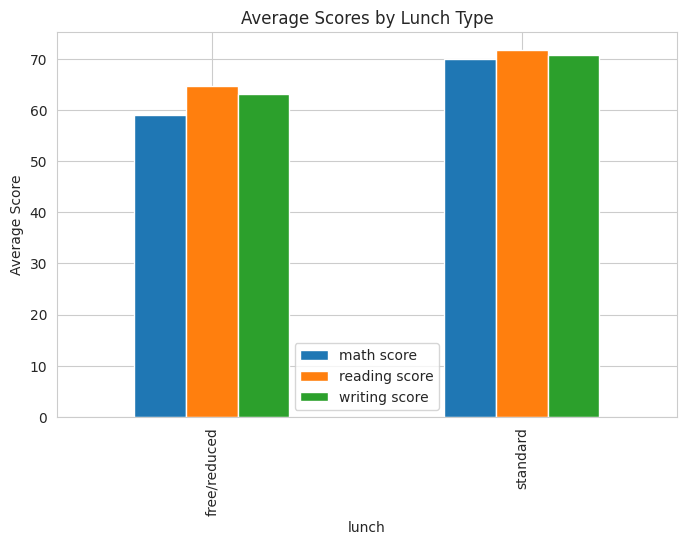

In [16]:
df.groupby("lunch")[["math score", "reading score", "writing score"]].mean().plot(kind="bar", figsize=(8,5))
plt.title("Average Scores by Lunch Type")
plt.ylabel("Average Score")
plt.show()

In [17]:
df.groupby("parental level of education")[["math score", "reading score", "writing score"]].mean().sort_values(by="math score")

,math score,reading score,writing score
parental level of education,,,
high school,62.137755,64.704082,62.448980
some high school,63.497207,66.938547,64.888268
some college,67.128319,69.460177,68.840708
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
master's degree,69.745763,75.372881,75.677966


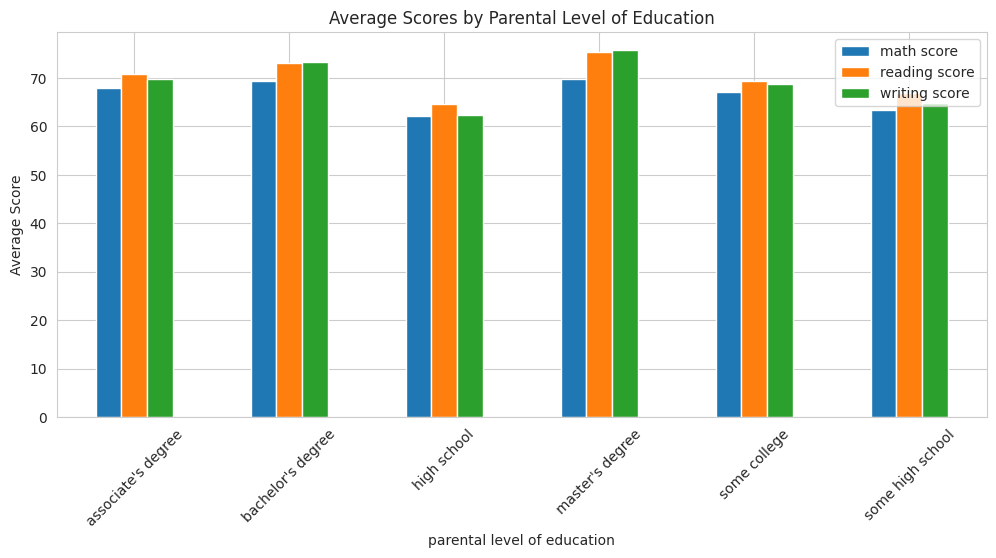

In [18]:
df.groupby("parental level of education")[["math score", "reading score", "writing score"]].mean().plot(kind="bar", figsize=(12,5))
plt.title("Average Scores by Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

In [19]:
corr = df[["math score", "reading score", "writing score", "average_score"]].corr()
corr

,math score,reading score,writing score,average_score
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
average_score,0.918746,0.970331,0.965667,1.000000


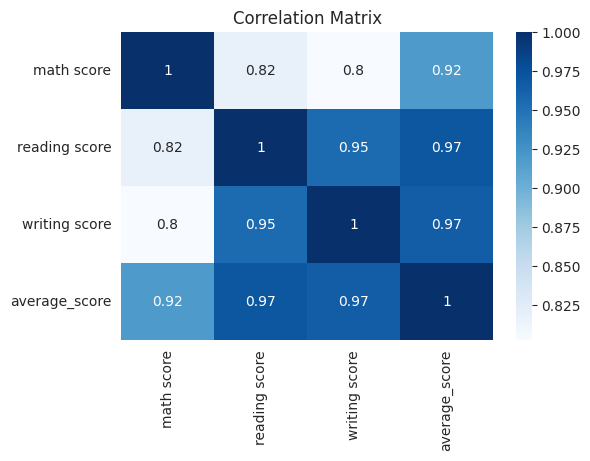

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

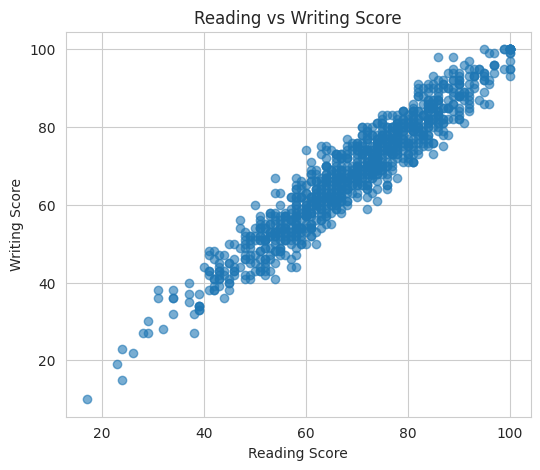

In [21]:
plt.figure(figsize=(6,5))
plt.scatter(df["reading score"], df["writing score"], alpha=0.6)
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.title("Reading vs Writing Score")
plt.show()

###Clustering model

<details>
<summary><b>Step 1: เลือก feature สำหรับ Clustering</b></summary>

ในงานนี้เราจะใช้คะแนน 3 วิชา:
- math score
- reading score
- writing score

เพราะต้องการจัดกลุ่มนักเรียนตามรูปแบบผลการเรียน

</details>

In [22]:
cluster_features = ["math score", "reading score", "writing score"]
X_cluster = df[cluster_features].copy()

print("Shape:", X_cluster.shape)
display(X_cluster.head())

Shape: (1000, 3)


,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


<details>
<summary><b>Step 2: Scale ข้อมูล</b></summary>

K-Means ใช้ระยะทางในการแบ่งกลุ่ม
ดังนั้นเราควรทำ Standardization ก่อน

สูตรของ Standardization คือ

z = (x - mean) / std

ซึ่งจะทำให้แต่ละ feature มีค่าเฉลี่ยใกล้ 0
และส่วนเบี่ยงเบนมาตรฐานใกล้ 1

</details>

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Shape after scaling:", X_scaled.shape)
print(X_scaled[:5])

Shape after scaling: (1000, 3)
[[ 0.39002351  0.19399858  0.39149181]
 [ 0.19207553  1.42747598  1.31326868]
 [ 1.57771141  1.77010859  1.64247471]
 [-1.25954302 -0.83389925 -1.58374436]
 [ 0.65395415  0.60515772  0.45733301]]


<details>
<summary><b>Step 3: หา K ที่เหมาะสมด้วย Elbow Method</b></summary>

เราจะลอง K หลายค่า แล้วดูค่า inertia
เพื่อหาจำนวนกลุ่มที่เหมาะสม

</details>

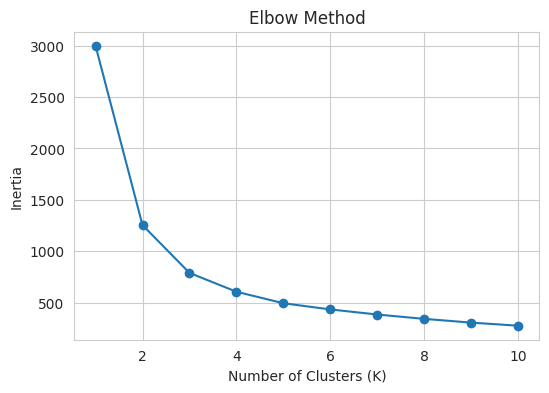

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

<details>
<summary><b>Step 4: ใช้ Silhouette Score ช่วยเลือก K</b></summary>

Silhouette Score ช่วยวัดว่าจุดใน cluster เดียวกันใกล้กันแค่ไหน
และห่างจาก cluster อื่นแค่ไหน

ยิ่งสูงยิ่งดี

</details>

In [27]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.4741
K=3, Silhouette Score=0.4060
K=4, Silhouette Score=0.3530
K=5, Silhouette Score=0.3336
K=6, Silhouette Score=0.2962
K=7, Silhouette Score=0.3048
K=8, Silhouette Score=0.2991
K=9, Silhouette Score=0.3055
K=10, Silhouette Score=0.3089


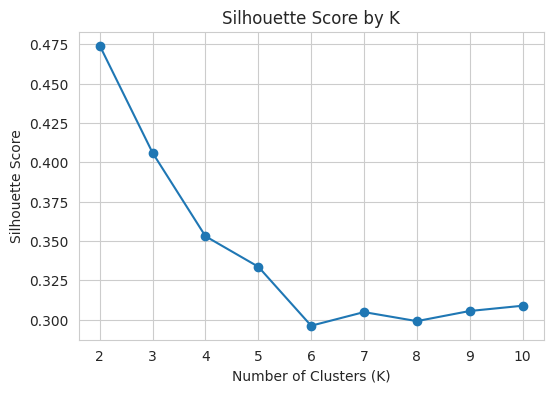

In [28]:
plt.figure(figsize=(6,4))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.show()

<details>
<summary><b>Step 5: Train K-Means Clustering</b></summary>

หลังจากดู Elbow Method และ Silhouette Score
เราจะเลือก K ที่เหมาะสมแล้ว train โมเดล K-Means

</details>

In [29]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

print("Cluster counts:")
print(df["cluster"].value_counts())

display(df[["math score", "reading score", "writing score", "cluster"]].head(20))

Cluster counts:
cluster
0    443
2    308
1    249
Name: count, dtype: int64


,math score,reading score,writing score,cluster
0,72,72,74,0
1,69,90,88,2
2,90,95,93,2
3,47,57,44,1
4,76,78,75,2
5,71,83,78,2
6,88,95,92,2
7,40,43,39,1
8,64,64,67,0
9,38,60,50,1


In [30]:
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(
    centers_original,
    columns=cluster_features
)

centers_df["cluster"] = range(k)
display(centers_df)

,math score,reading score,writing score,cluster
0,65.338600,68.458239,67.821670,0
1,48.096386,50.670683,48.485944,1
2,81.714286,85.146104,84.207792,2


In [31]:
cluster_summary = df.groupby("cluster")[["math score", "reading score", "writing score"]].mean()
display(cluster_summary)

,math score,reading score,writing score
cluster,,,
0,65.338600,68.458239,67.821670
1,48.096386,50.670683,48.485944
2,81.714286,85.146104,84.207792


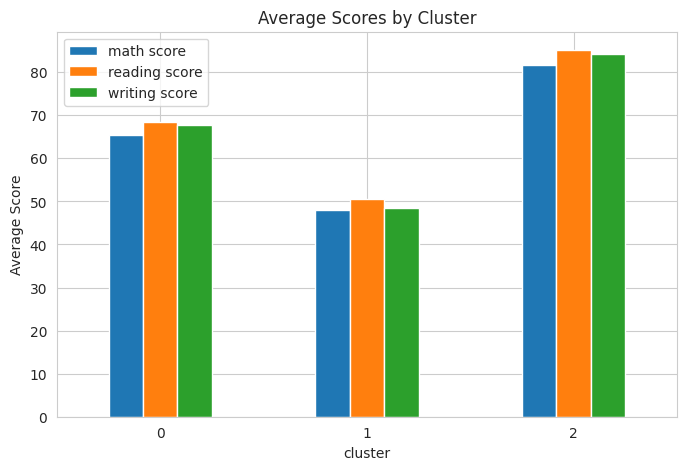

In [32]:
cluster_summary.plot(kind="bar", figsize=(8,5))
plt.title("Average Scores by Cluster")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()

<details>
<summary><b>Step 6: ลดมิติด้วย PCA เพื่อแสดงผล 2D</b></summary>

เราจะใช้ PCA เพื่อลดข้อมูลจาก 3 มิติ เหลือ 2 มิติ
สำหรับการ plot ให้มองเห็น cluster ได้ง่ายขึ้น

</details>

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.90614325 0.07886171]


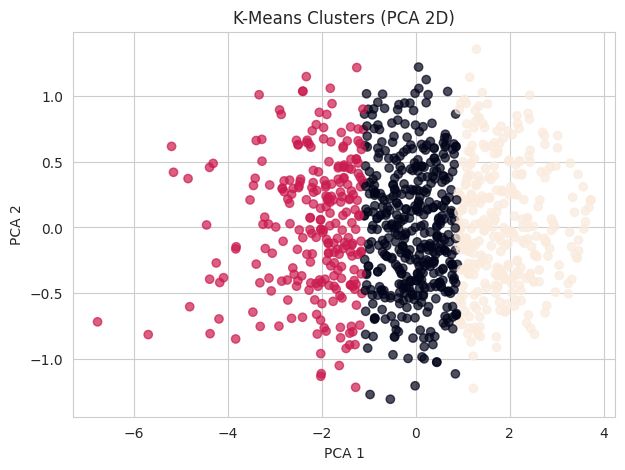

In [34]:
plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (PCA 2D)")
plt.show()

In [35]:
for c in sorted(df["cluster"].unique()):
    print(f"\n===== Cluster {c} =====")
    display(df[df["cluster"] == c][["math score", "reading score", "writing score"]].head(10))


===== Cluster 0 =====


,math score,reading score,writing score
0,72,72,74
8,64,64,67
12,65,81,73
13,78,72,70
15,69,75,78
20,66,69,63
21,65,75,70
23,69,73,73
24,74,71,80
25,73,74,72



===== Cluster 1 =====


,math score,reading score,writing score
3,47,57,44
7,40,43,39
9,38,60,50
10,58,54,52
11,40,52,43
14,50,53,58
17,18,32,28
18,46,42,46
19,54,58,61
22,44,54,53



===== Cluster 2 =====


,math score,reading score,writing score
1,69,90,88
2,90,95,93
4,76,78,75
5,71,83,78
6,88,95,92
16,88,89,86
34,97,87,82
35,81,81,79
36,74,81,83
38,75,90,88


* Cluster 0 = High Performance
* Cluster 1 = Medium Performance
* Cluster 2 = Low Performance

In [36]:
# สมมติหลังดูค่าเฉลี่ยแล้วค่อย map ใหม่
cluster_names = {
    0: "Group A",
    1: "Group B",
    2: "Group C"
}

df["cluster_name"] = df["cluster"].map(cluster_names)
display(df[["math score", "reading score", "writing score", "cluster", "cluster_name"]].head(20))

,math score,reading score,writing score,cluster,cluster_name
0,72,72,74,0,Group A
1,69,90,88,2,Group C
2,90,95,93,2,Group C
3,47,57,44,1,Group B
4,76,78,75,2,Group C
5,71,83,78,2,Group C
6,88,95,92,2,Group C
7,40,43,39,1,Group B
8,64,64,67,0,Group A
9,38,60,50,1,Group B


#Conclusion
In the clustering task, K-Means was applied to group students based on their mathematics, reading, and writing scores. Before clustering, the features were standardized using StandardScaler to ensure equal contribution of each score variable to the Euclidean distance calculation. The optimal number of clusters was explored using the Elbow Method and Silhouette Score. After selecting an appropriate value of
𝐾
K, the final K-Means model assigned each student to a cluster. The resulting groups were then analyzed using cluster centroids and average score summaries, and visualized in two dimensions using PCA.